# Amazon Music OPE gate

Question: if an OPE estimate is used to decide whether a candidate gets an A/B slot, what decisions does it make?


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
gate = pd.read_csv(ROOT / "results" / "gate_results.csv")
bootstrap = pd.read_csv(ROOT / "results" / "bootstrap_summary.csv")
policy = pd.read_csv(ROOT / "results" / "policy_summary.csv").iloc[0]

pd.DataFrame([policy])


,logging_policy_value_D2,logging_reported_lower,logging_reported_upper,target_policy_reference_D1,target_reported_lower,target_reported_upper,held_out_target_uplift,held_out_uplift_envelope_lower,held_out_uplift_envelope_upper
0,1.250246,1.246222,1.254325,1.259499,1.255731,1.263091,0.0074,0.00112,0.013536


Held-out uplift: **+0.74%**.  
Conservative range from the reported intervals: **+0.11% to +1.35%**.

Bars inside that range are left unscored.


In [5]:
bootstrap

,estimator,mean_estimate,bootstrap_sd,median_signed_error,median_absolute_error,p90_absolute_error,median_estimated_uplift,p10_estimated_uplift,p90_estimated_uplift,reported_interval_contains_gt_rate
0,INTERPOL-3,1.288986,0.042288,0.029258,0.033219,0.076720,0.030031,-0.013358,0.067733,0.966667
1,PBM-D,1.315101,0.005545,0.056640,0.056640,0.060635,0.051129,0.047780,0.054950,0.000000


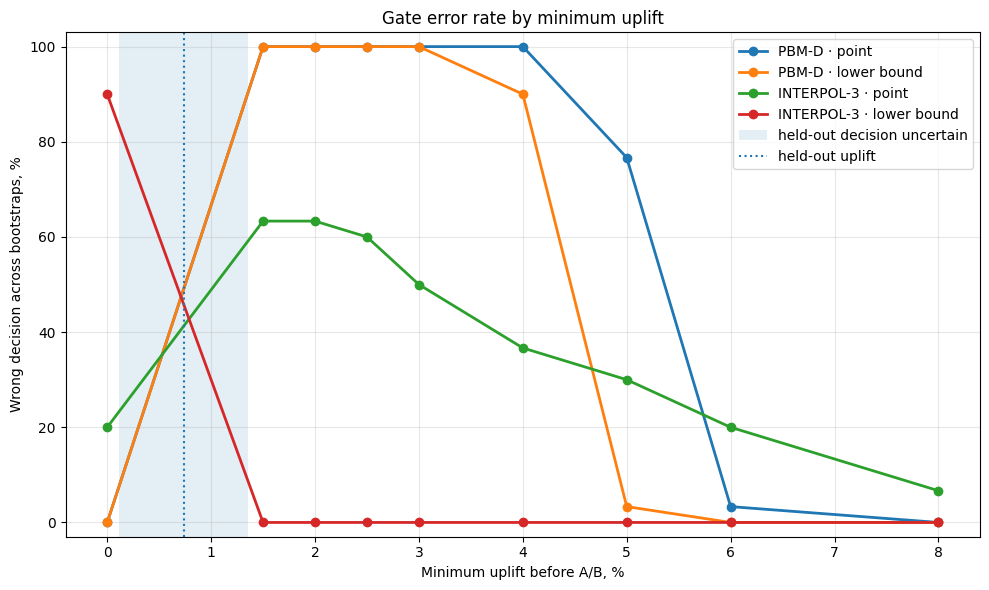

In [6]:
plot_gate = gate[gate["held_out_decision"] != "uncertain"].copy()

fig, ax = plt.subplots(figsize=(10, 6))

for estimator, rule, label in [
    ("PBM-D", "point", "PBM-D · point"),
    ("PBM-D", "lower_bound", "PBM-D · lower bound"),
    ("INTERPOL-3", "point", "INTERPOL-3 · point"),
    ("INTERPOL-3", "lower_bound", "INTERPOL-3 · lower bound"),
]:
    g = plot_gate[
        (plot_gate["estimator"] == estimator) &
        (plot_gate["gate_rule"] == rule)
    ].sort_values("required_uplift_pct")

    ax.plot(
        g["required_uplift_pct"],
        g["wrong_decision_rate_pct"],
        marker="o",
        linewidth=2,
        label=label,
    )

ax.axvspan(
    policy["held_out_uplift_envelope_lower"] * 100,
    policy["held_out_uplift_envelope_upper"] * 100,
    alpha=0.12,
    label="held-out decision uncertain",
)
ax.axvline(
    policy["held_out_target_uplift"] * 100,
    linestyle=":",
    linewidth=1.5,
    label="held-out uplift",
)

ax.set_title("Gate error rate by minimum uplift")
ax.set_xlabel("Minimum uplift before A/B, %")
ax.set_ylabel("Wrong decision across bootstraps, %")
ax.set_ylim(-3, 103)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


At 1.5–3% bars, PBM-D passes the candidate in all 30 resamples although the held-out result is below the bar.

At a 0% bar, INTERPOL-3 with the lower-bound rule rejects it in 27/30 resamples although the held-out result is above the bar.
